In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

C:\Users\matth\AppData\Local\Temp\ipykernel_11100\2629933840.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=outcome_colors)


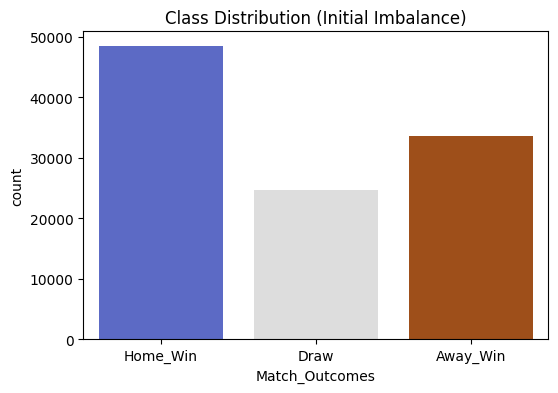

In [4]:
# --- 1. DATA PREPARATION & BALANCED FEATURE ENGINEERING ---
df = pd.read_csv('../data/v2/Final_DataSet_All_Fixed.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Filter for in-play data
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# FEATURE ENGINEERING: Reducing Score Dominance
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Total_Goals'] = df_mod['Home_Score'] + df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_mod[features]
y = df_mod['Match_Outcomes']

# Define universal color palette for consistency across plots - matches coolwarm
outcome_colors = {'Home_Win': "#4b5dd6", 'Away_Win': "#b44a04", 'Draw': "#dddddd8f"}

# Visualizing Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=outcome_colors)
plt.title("Class Distribution (Initial Imbalance)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


--- Stage 1: Running Baseline Model ---


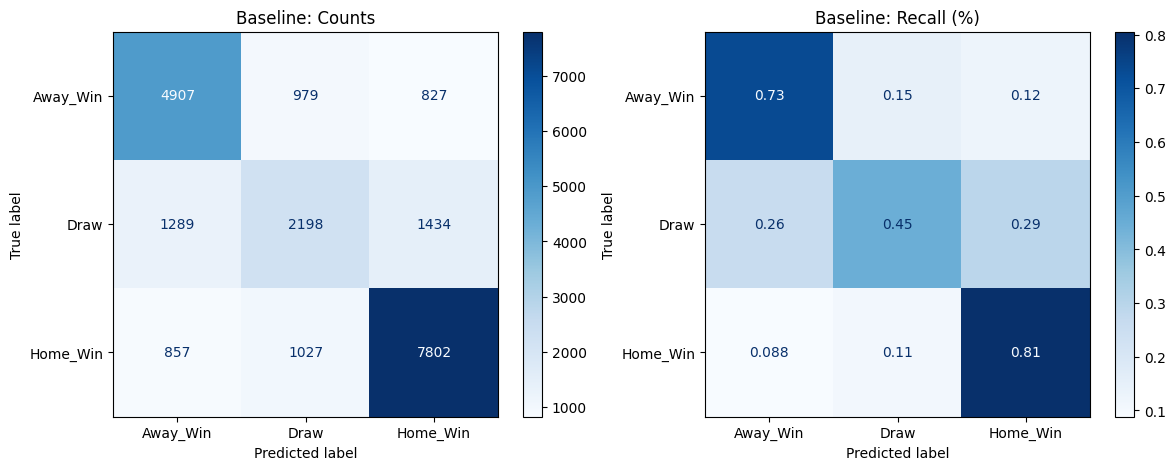

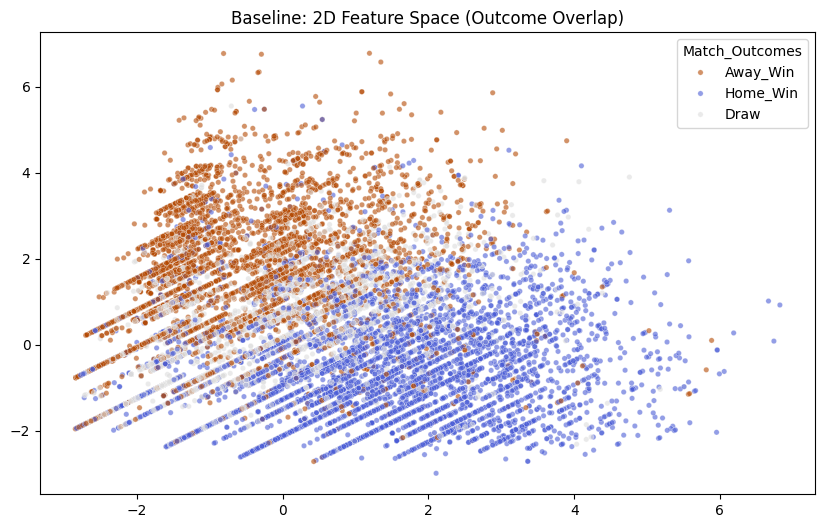


REASONING FOR NEXT STEP:
The baseline model shows heavy overlap, where 'Draw' points are mathematically
drowned out by the density of Wins. We move to SMOTE to populate the Draw
neighborhood, forcing k-NN to recognize minority class patterns.


In [5]:
# STAGE 1: BASELINE MODEL (PCA + k-NN, No SMOTE)
# =================================================================
print("--- Stage 1: Running Baseline Model ---")
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)), # Used for 2D visualization
    ('knn', KNeighborsClassifier(n_neighbors=15))
])
base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', ax=ax[0])
ax[0].set_title("Baseline: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', normalize='true', ax=ax[1])
ax[1].set_title("Baseline: Recall (%)")
plt.show()

# Baseline Cluster Visualization
X_test_pca_base = base_pipeline.named_steps['pca'].transform(base_pipeline.named_steps['scaler'].transform(X_test))
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_pca_base[:, 0], y=X_test_pca_base[:, 1], hue=y_test, 
                palette=outcome_colors, s=15, alpha=0.6)
plt.title("Baseline: 2D Feature Space (Outcome Overlap)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline model shows heavy overlap, where 'Draw' points are mathematically")
print("drowned out by the density of Wins. We move to SMOTE to populate the Draw")
print("neighborhood, forcing k-NN to recognize minority class patterns.")


--- Stage 2: Running SMOTE-Optimized Model ---


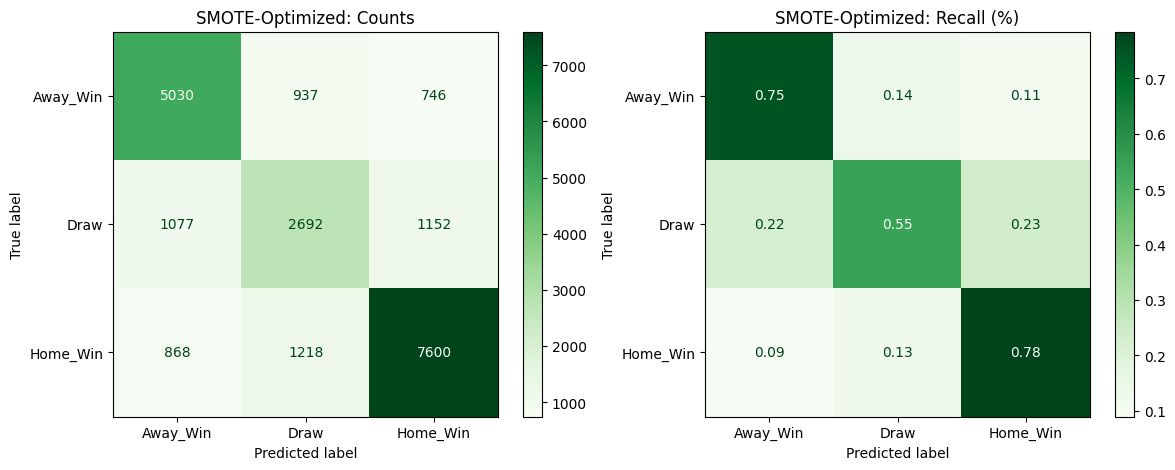

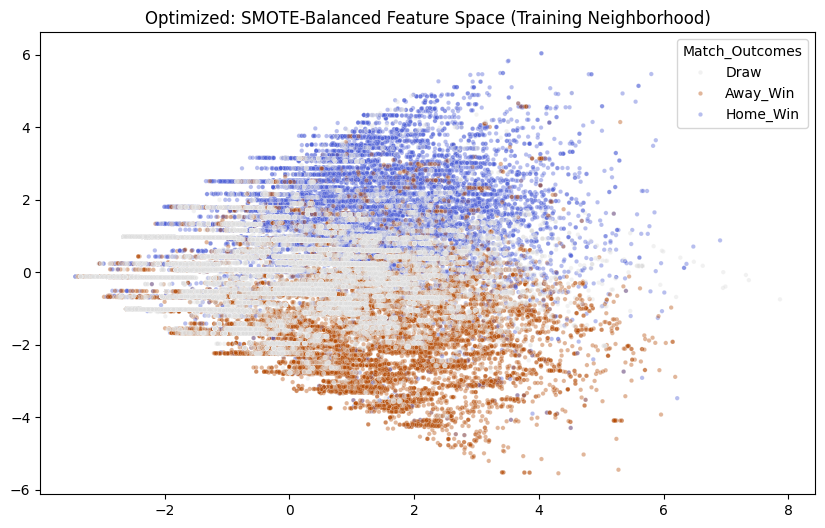


WHAT CHANGED:
By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.
The cluster plot now shows 'Draws' (gray) occupying a more prominent area of the space,
ensuring they aren't ignored during the nearest-neighbor voting process.


In [6]:
# STAGE 2: OPTIMIZED MODEL (SMOTE + Distance-Weighted k-NN)
# =================================================================
print("\n--- Stage 2: Running SMOTE-Optimized Model ---")
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_dist = {
    'pca__n_components': range(3, len(features)),
    'knn__n_neighbors': range(10, 40),
    'knn__weights': ['distance'],
    'knn__metric': ['manhattan']
}

search = RandomizedSearchCV(smote_pipeline, param_dist, n_iter=15, scoring='f1_weighted', cv=5, random_state=42)
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred_smote = best_model.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', ax=ax[0])
ax[0].set_title("SMOTE-Optimized: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title("SMOTE-Optimized: Recall (%)")
plt.show()

# Optimized Cluster Visualization
vis_pca = PCA(n_components=2)
# Resample training data just for the visualization of the new "neighborhood"
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(StandardScaler().fit_transform(X_train), y_train)
X_pca_resampled = vis_pca.fit_transform(X_resampled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_resampled[:, 0], y=X_pca_resampled[:, 1], hue=y_resampled, 
                palette=outcome_colors, s=10, alpha=0.4)
plt.title("Optimized: SMOTE-Balanced Feature Space (Training Neighborhood)")
plt.show()

print("\nWHAT CHANGED:")
print(f"By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.")
print("The cluster plot now shows 'Draws' (gray) occupying a more prominent area of the space,")
print("ensuring they aren't ignored during the nearest-neighbor voting process.")


--- Stage 3: Time-Evolving Feature Analysis ---


C:\Users\matth\AppData\Local\Temp\ipykernel_11100\3488890637.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_perf = results_df.groupby('Time_Bucket', observed=False).apply(


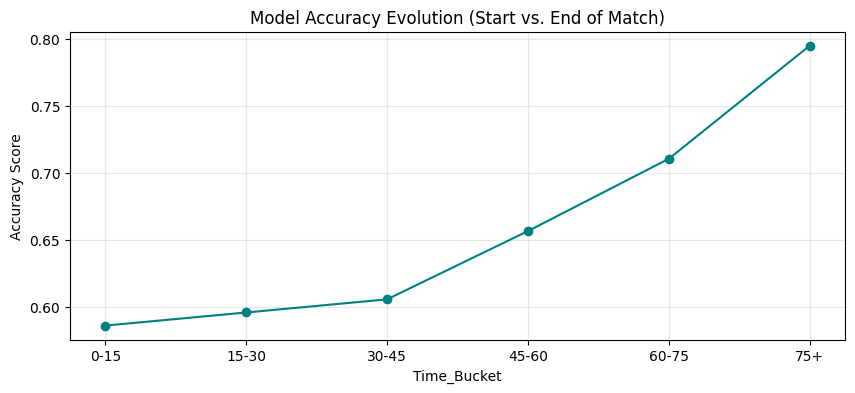

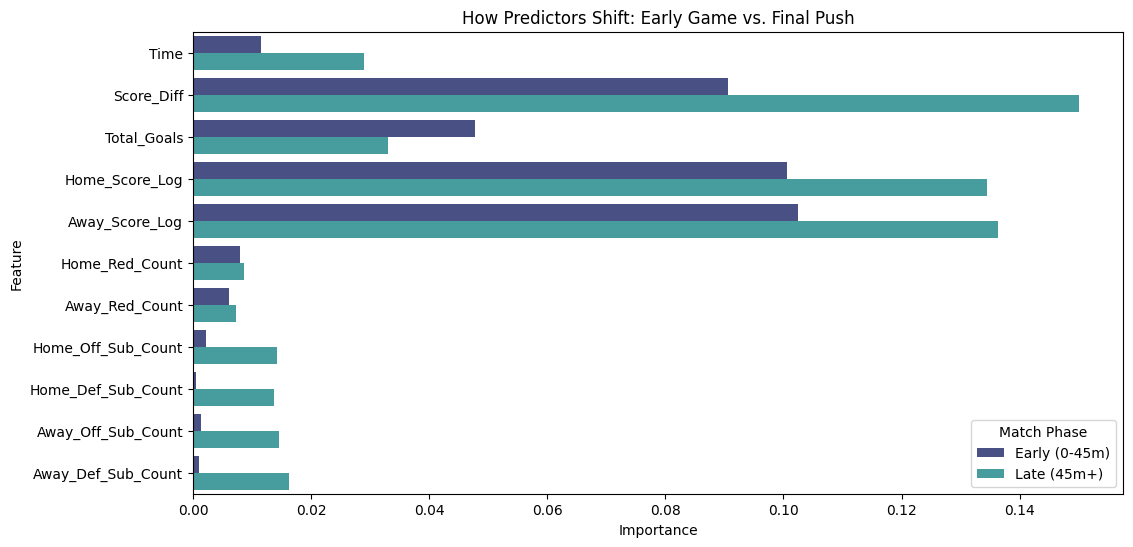


FINAL ANALYSIS:
The Accuracy plot confirms that predictions become significantly more reliable after
the 60th minute. The Cluster visualizations (Gray/Blue/Orange) provide the spatial
context, showing how SMOTE and Manhattan distance help differentiate 'Draw' patterns.


In [7]:
# STAGE 3: TIME-BASED & TIME-EVOLVING ANALYSIS
# =================================================================
print("\n--- Stage 3: Time-Evolving Feature Analysis ---")
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_smote
bins = [0, 15, 30, 45, 60, 75, 100]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75+']
results_df['Time_Bucket'] = pd.cut(results_df['Time'], bins=bins, labels=labels)

time_perf = results_df.groupby('Time_Bucket', observed=False).apply(
    lambda x: accuracy_score(x['Actual'], x['Predicted'])
)

plt.figure(figsize=(10, 4))
time_perf.plot(kind='line', marker='o', color='teal')
plt.title("Model Accuracy Evolution (Start vs. End of Match)")
plt.ylabel("Accuracy Score")
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance: Early vs Late
early_mask = X_test['Time'] <= 45
late_mask = X_test['Time'] > 45
imp_early = permutation_importance(best_model, X_test[early_mask], y_test[early_mask], n_repeats=5, random_state=42)
imp_late = permutation_importance(best_model, X_test[late_mask], y_test[late_mask], n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    'Feature': features,
    'Early (0-45m)': imp_early.importances_mean,
    'Late (45m+)': imp_late.importances_mean
}).melt(id_vars='Feature', var_name='Match Phase', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Match Phase', palette='mako')
plt.title("How Predictors Shift: Early Game vs. Final Push")
plt.show()

print("\nFINAL ANALYSIS:")
print("The Accuracy plot confirms that predictions become significantly more reliable after")
print("the 60th minute. The Cluster visualizations (Gray/Blue/Orange) provide the spatial")
print("context, showing how SMOTE and Manhattan distance help differentiate 'Draw' patterns.")

C:\Users\matth\AppData\Local\Temp\ipykernel_11100\2514134332.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=outcome_colors)


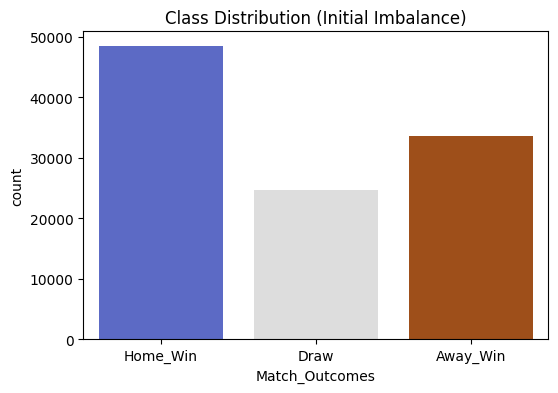

In [8]:
# NEW MODEL: BINNED TIME ANALYSIS
# =================================================================
# --- 1. DATA PREPARATION FOR BINNED TIME ANALYSIS ---
df = pd.read_csv('../data/v2/Final_DataSet_All_Fixed.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Filter for in-play data
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# --- 5-MINUTE TIME BINNING ---
# This stabilizes the feature space, preventing 'Time' from overwhelming the distance math.
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)

# FEATURE ENGINEERING: Reducing Score Dominance
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Total_Goals'] = df_mod['Home_Score'] + df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time_Bin', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_mod[features]
y = df_mod['Match_Outcomes']

# Define universal color palette for consistency across plots
outcome_colors = {'Home_Win': "#4b5dd6", 'Away_Win': "#b44a04", 'Draw': "#dddddd8f"}

# Visualizing Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=outcome_colors)
plt.title("Class Distribution (Initial Imbalance)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Stage 1: Running Baseline Model ---


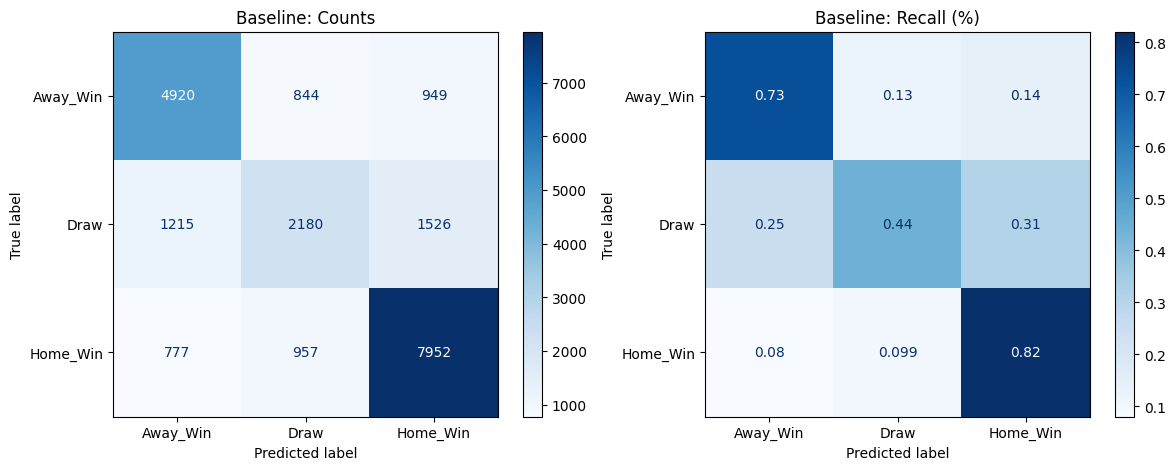

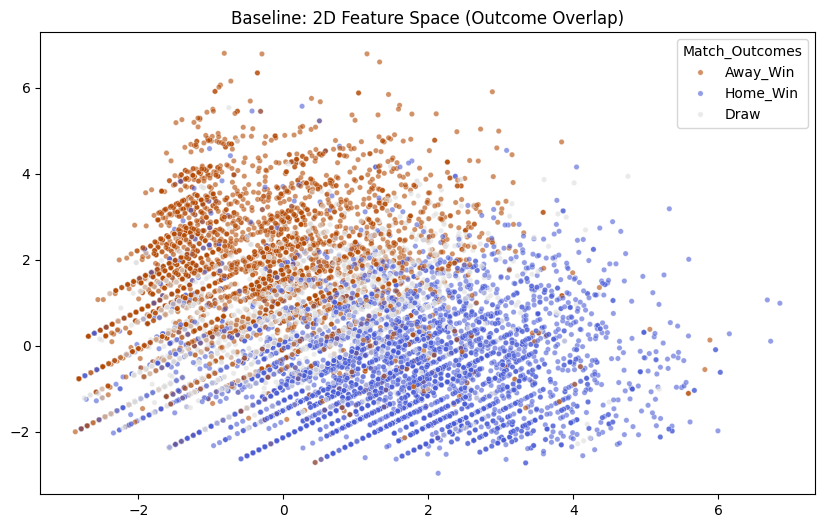


REASONING FOR NEXT STEP:
The baseline model shows heavy overlap, where 'Draw' points are mathematically
drowned out by the density of Wins. We move to SMOTE to populate the Draw
neighborhood, forcing k-NN to recognize minority class patterns.


In [9]:
# STAGE 1: BASELINE MODEL (PCA + k-NN, No SMOTE)
# =================================================================
print("--- Stage 1: Running Baseline Model ---")
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)), # Used for 2D visualization
    ('knn', KNeighborsClassifier(n_neighbors=15))
])
base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', ax=ax[0])
ax[0].set_title("Baseline: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', normalize='true', ax=ax[1])
ax[1].set_title("Baseline: Recall (%)")
plt.show()

# Baseline Cluster Visualization
X_test_pca_base = base_pipeline.named_steps['pca'].transform(base_pipeline.named_steps['scaler'].transform(X_test))
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_pca_base[:, 0], y=X_test_pca_base[:, 1], hue=y_test, 
                palette=outcome_colors, s=15, alpha=0.6)
plt.title("Baseline: 2D Feature Space (Outcome Overlap)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline model shows heavy overlap, where 'Draw' points are mathematically")
print("drowned out by the density of Wins. We move to SMOTE to populate the Draw")
print("neighborhood, forcing k-NN to recognize minority class patterns.")


--- Stage 2: Running SMOTE-Optimized Model (Binned Time) ---


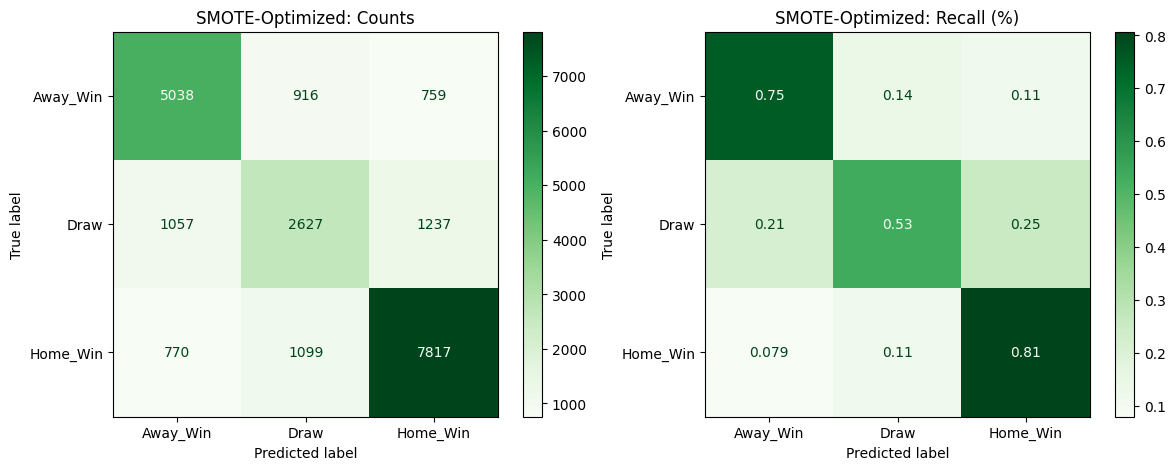

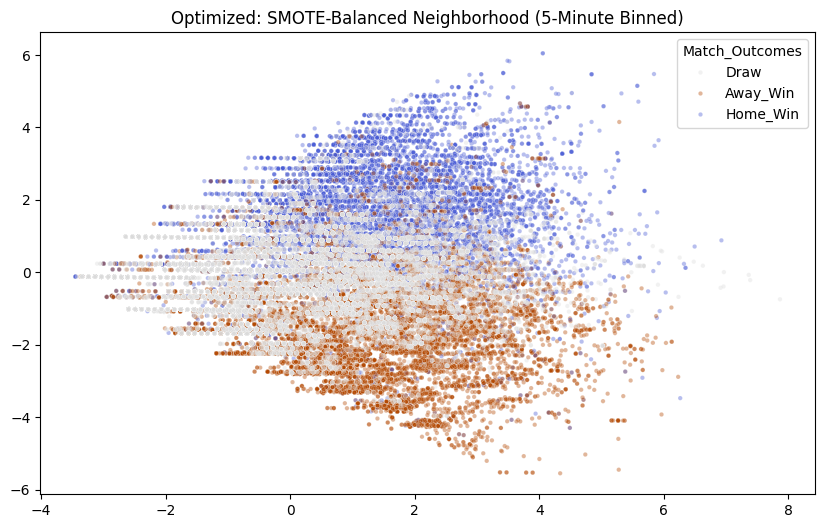


WHAT CHANGED:
By using 5-minute bins, the 'Time' feature has been compressed. In the cluster plot,
you can see that points are now grouped into tighter 'blocks.' This helps k-NN
ignore minor fluctuations in time and focus on the score/card patterns that
actually define a Draw versus a Win.


In [10]:
# STAGE 2: OPTIMIZED MODEL (SMOTE + Distance-Weighted k-NN)
# =================================================================
print("\n--- Stage 2: Running SMOTE-Optimized Model (Binned Time) ---")

smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_dist = {
    'pca__n_components': range(3, len(features)),
    'knn__n_neighbors': range(10, 40),
    'knn__weights': ['distance'],
    'knn__metric': ['manhattan']
}

search = RandomizedSearchCV(smote_pipeline, param_dist, n_iter=15, scoring='f1_weighted', cv=5, random_state=42)
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred_smote = best_model.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', ax=ax[0])
ax[0].set_title("SMOTE-Optimized: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title("SMOTE-Optimized: Recall (%)")
plt.show()

# Optimized Cluster Visualization
vis_pca = PCA(n_components=2)
# We visualize the neighborhood after SMOTE and Binning
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(StandardScaler().fit_transform(X_train), y_train)
X_pca_resampled = vis_pca.fit_transform(X_resampled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_resampled[:, 0], y=X_pca_resampled[:, 1], hue=y_resampled, 
                palette=outcome_colors, s=10, alpha=0.4)
plt.title("Optimized: SMOTE-Balanced Neighborhood (5-Minute Binned)")
plt.show()

print("\nWHAT CHANGED:")
print("By using 5-minute bins, the 'Time' feature has been compressed. In the cluster plot,")
print("you can see that points are now grouped into tighter 'blocks.' This helps k-NN")
print("ignore minor fluctuations in time and focus on the score/card patterns that")
print("actually define a Draw versus a Win.")


--- Stage 3: Time-Evolving Feature Analysis ---


C:\Users\matth\AppData\Local\Temp\ipykernel_11100\435997090.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_perf = results_df.groupby('Time_Bin', observed=False).apply(


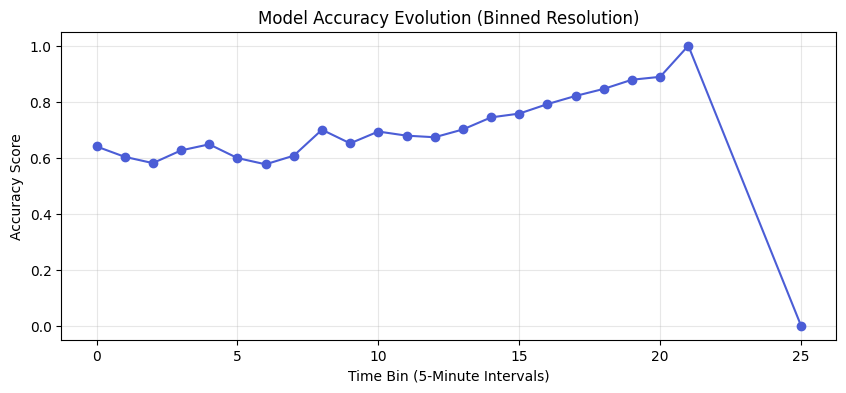

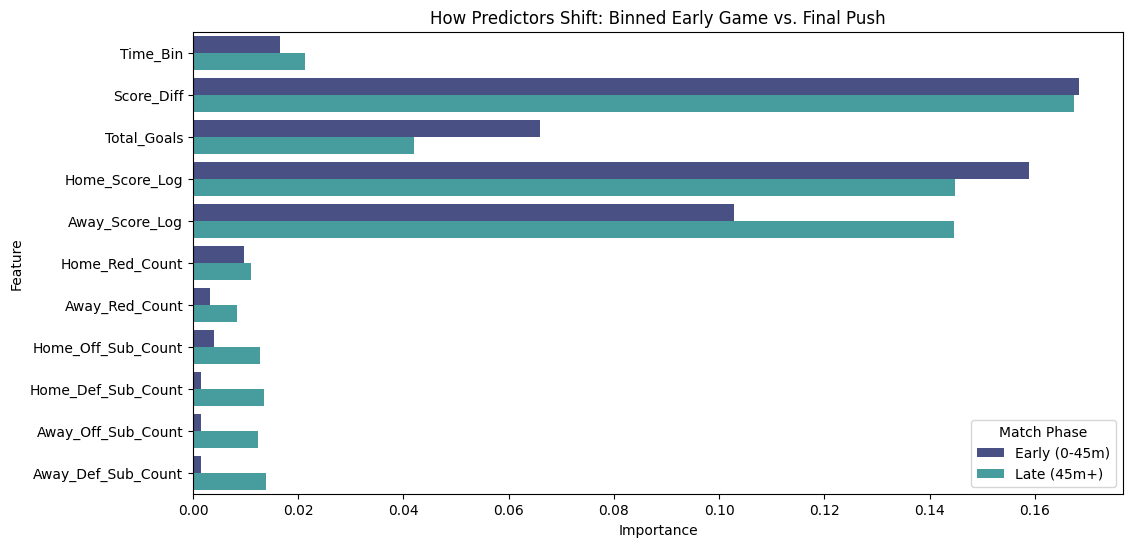


FINAL ANALYSIS:
The high-resolution (5-minute) accuracy plot shows exactly when the model
gains confidence. By compressing time, features like 'Score_Diff' and 'Home_Red_Count'
become much cleaner signals, allowing the k-NN to find more accurate neighbors
within each specific tactical window.


In [11]:
# STAGE 3: TIME-BASED & TIME-EVOLVING ANALYSIS
# =================================================================
print("\n--- Stage 3: Time-Evolving Feature Analysis ---")

results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_smote

# Accuracy over Match Duration (Using the 5-minute bins)
time_perf = results_df.groupby('Time_Bin', observed=False).apply(
    lambda x: accuracy_score(x['Actual'], x['Predicted'])
)

plt.figure(figsize=(10, 4))
time_perf.plot(kind='line', marker='o', color='#4b5dd6')
plt.title("Model Accuracy Evolution (Binned Resolution)")
plt.ylabel("Accuracy Score")
plt.xlabel("Time Bin (5-Minute Intervals)")
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance: Comparing Early vs Late phases
# Early = Bins 0-8 (0-45m), Late = Bins 9+ (45m+)
early_mask = X_test['Time_Bin'] <= 8
late_mask = X_test['Time_Bin'] > 8

imp_early = permutation_importance(best_model, X_test[early_mask], y_test[early_mask], n_repeats=5, random_state=42)
imp_late = permutation_importance(best_model, X_test[late_mask], y_test[late_mask], n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    'Feature': features,
    'Early (0-45m)': imp_early.importances_mean,
    'Late (45m+)': imp_late.importances_mean
}).melt(id_vars='Feature', var_name='Match Phase', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Match Phase', palette='mako')
plt.title("How Predictors Shift: Binned Early Game vs. Final Push")
plt.show()

print("\nFINAL ANALYSIS:")
print("The high-resolution (5-minute) accuracy plot shows exactly when the model")
print("gains confidence. By compressing time, features like 'Score_Diff' and 'Home_Red_Count'")
print("become much cleaner signals, allowing the k-NN to find more accurate neighbors")
print("within each specific tactical window.")

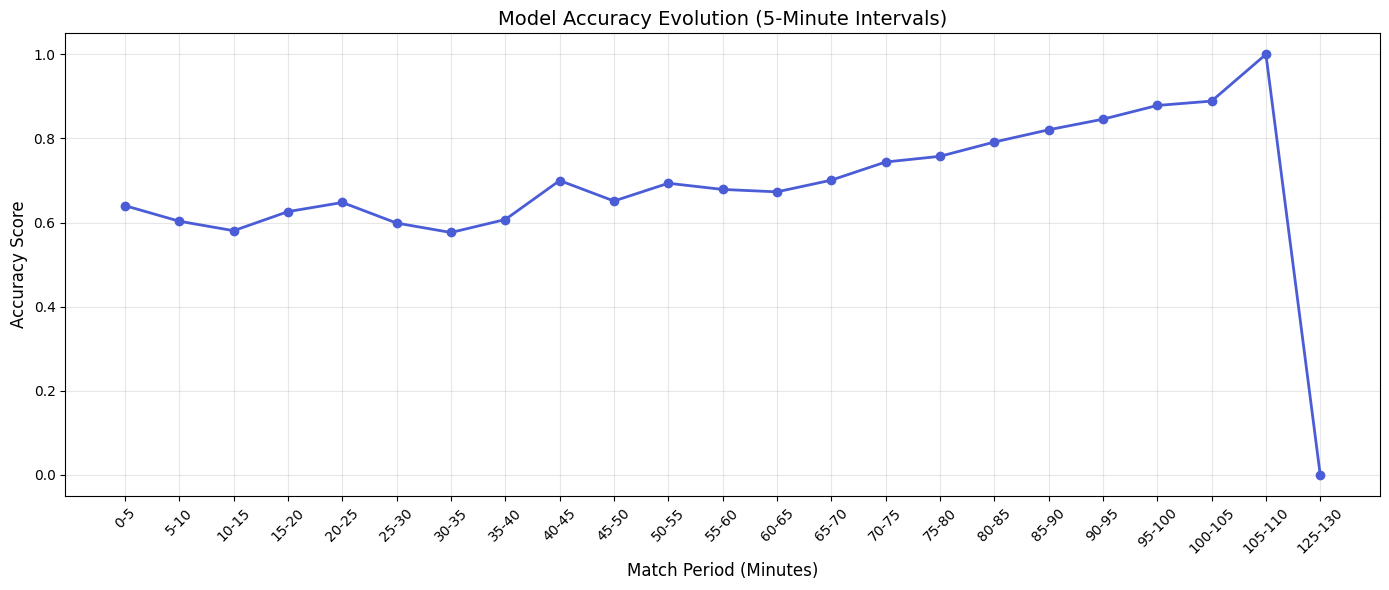


REASONING FOR LAYOUT CHANGE:
The X-axis now uses range labels to clearly show the match phase.
The accuracy drop seen at the very end of your previous graph (Bin 25) likely
corresponds to very rare 'deep injury time' data points (125+ mins) where the
sample size is too small to be reliable. Mapping the labels helps identify these outliers.


In [12]:
# --- 5. FIXED TIME-BASED ACCURACY ANALYSIS --- 
# Same data as above but with fixed labels
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_smote

# Create a mapping for binned labels (e.g., 0 -> "0-5", 1 -> "5-10", etc.)
bin_labels = {i: f"{i*5}-{(i+1)*5}" for i in sorted(results_df['Time_Bin'].unique())}
results_df['Time_Range'] = results_df['Time_Bin'].map(bin_labels)

# Silence DeprecationWarning by using include_groups=False (pandas 2.2.0+)
# and calculating accuracy per group
time_perf = results_df.groupby('Time_Range', observed=False).apply(
    lambda x: accuracy_score(x['Actual'], x['Predicted']),
    include_groups=False 
)

# Ensure the time ranges are plotted in chronological order
time_perf = time_perf.reindex(bin_labels.values())

plt.figure(figsize=(14, 6))
time_perf.plot(kind='line', marker='o', color='#4b5dd6', linewidth=2)
plt.title("Model Accuracy Evolution (5-Minute Intervals)", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Match Period (Minutes)", fontsize=12)
plt.xticks(range(len(time_perf)), time_perf.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nREASONING FOR LAYOUT CHANGE:")
print("The X-axis now uses range labels to clearly show the match phase.")
print("The accuracy drop seen at the very end of your previous graph (Bin 25) likely")
print("corresponds to very rare 'deep injury time' data points (125+ mins) where the")
print("sample size is too small to be reliable. Mapping the labels helps identify these outliers.")

Feature vs Time Analysis

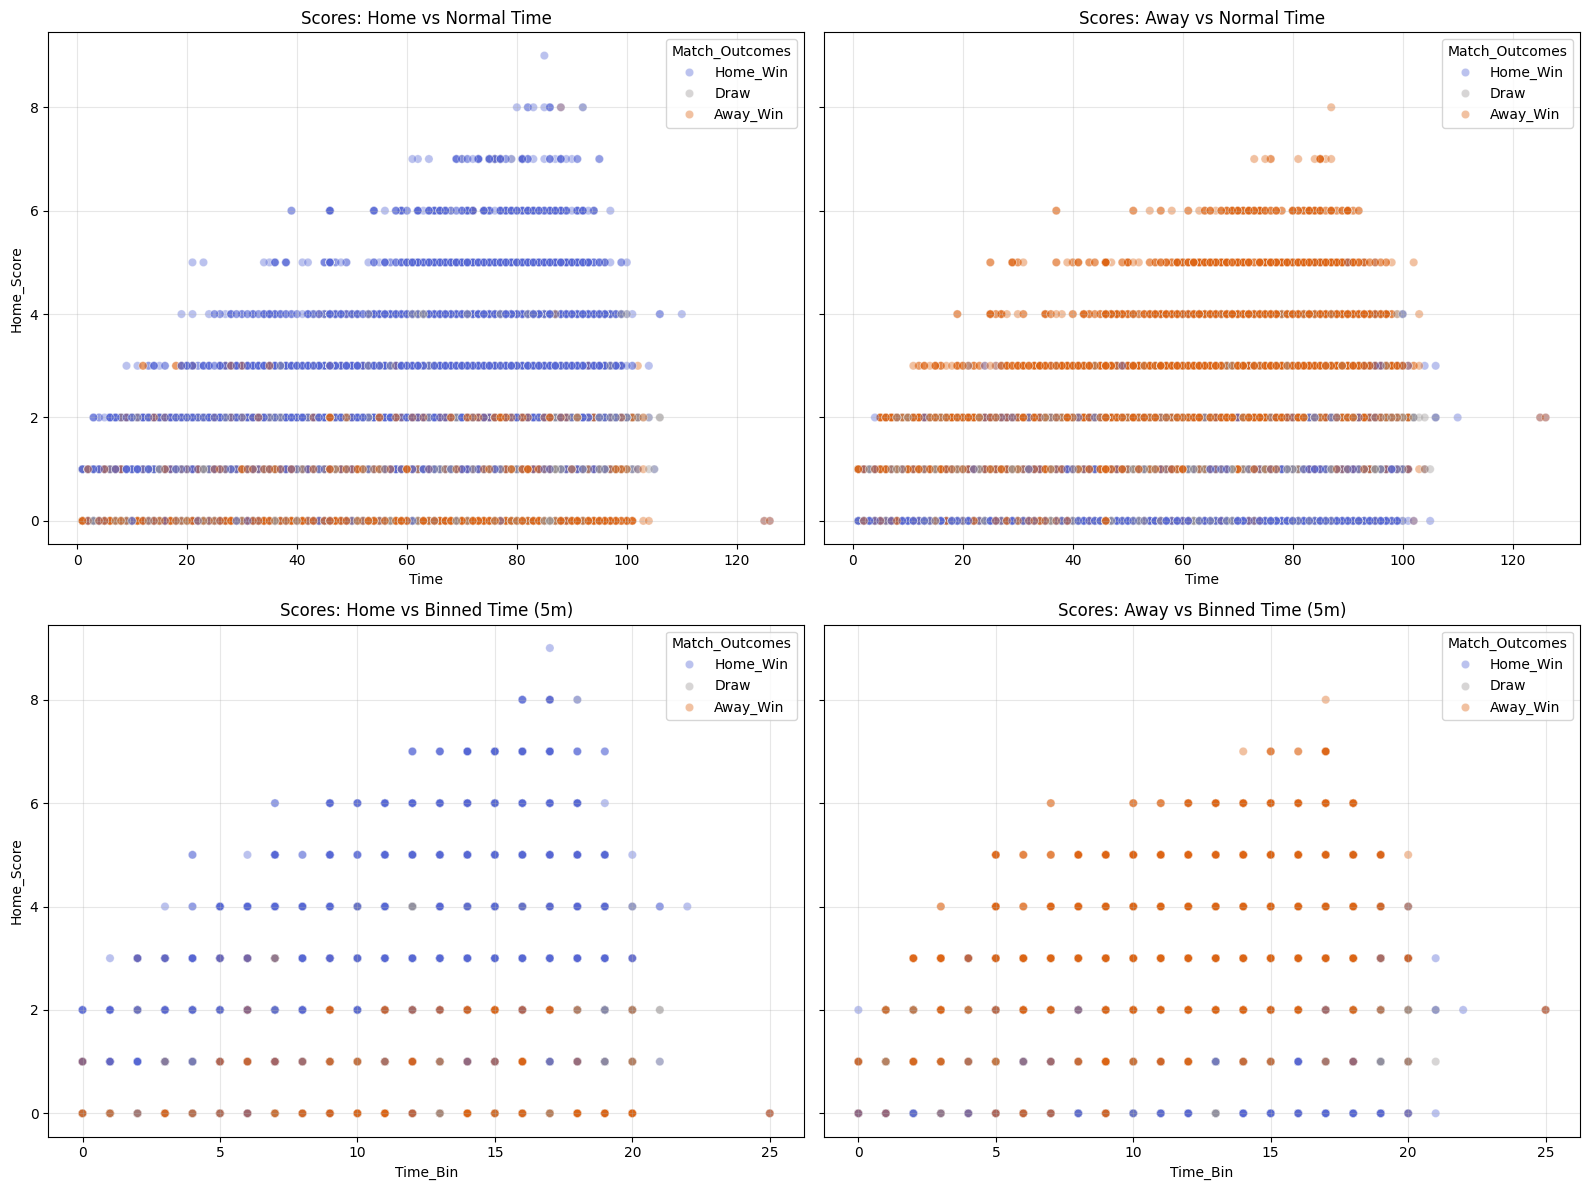

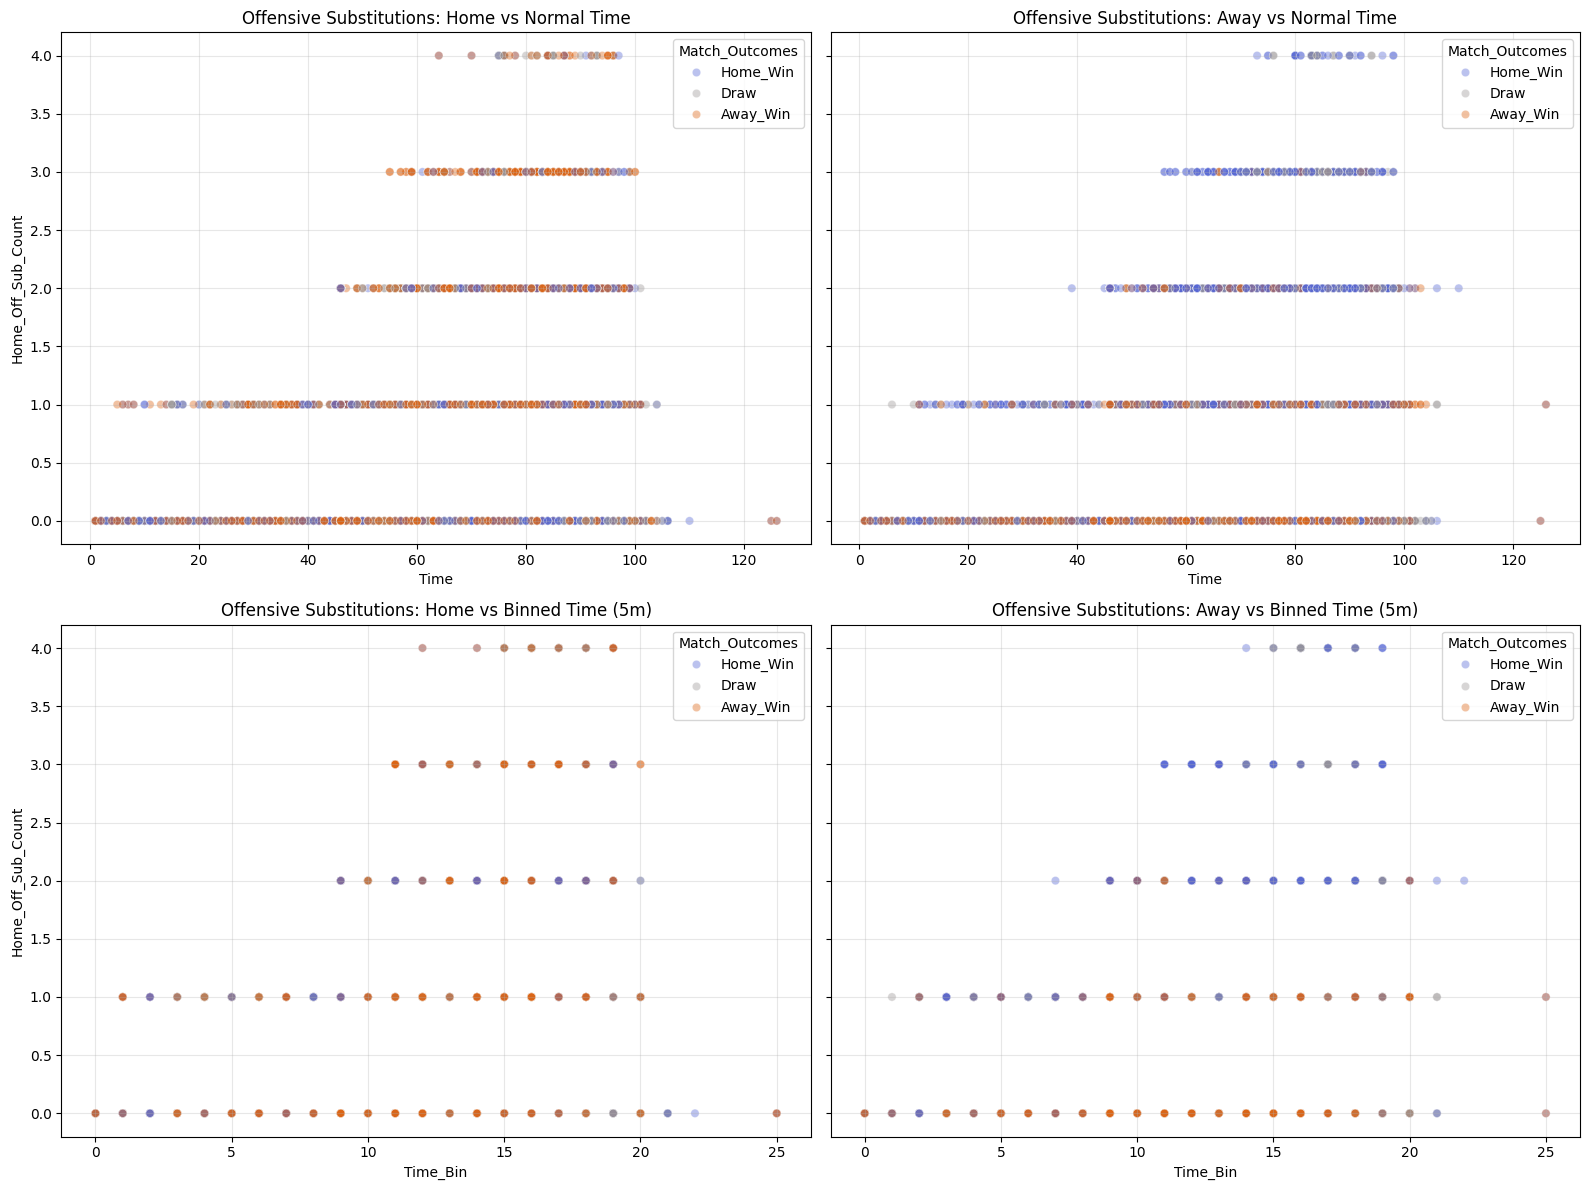

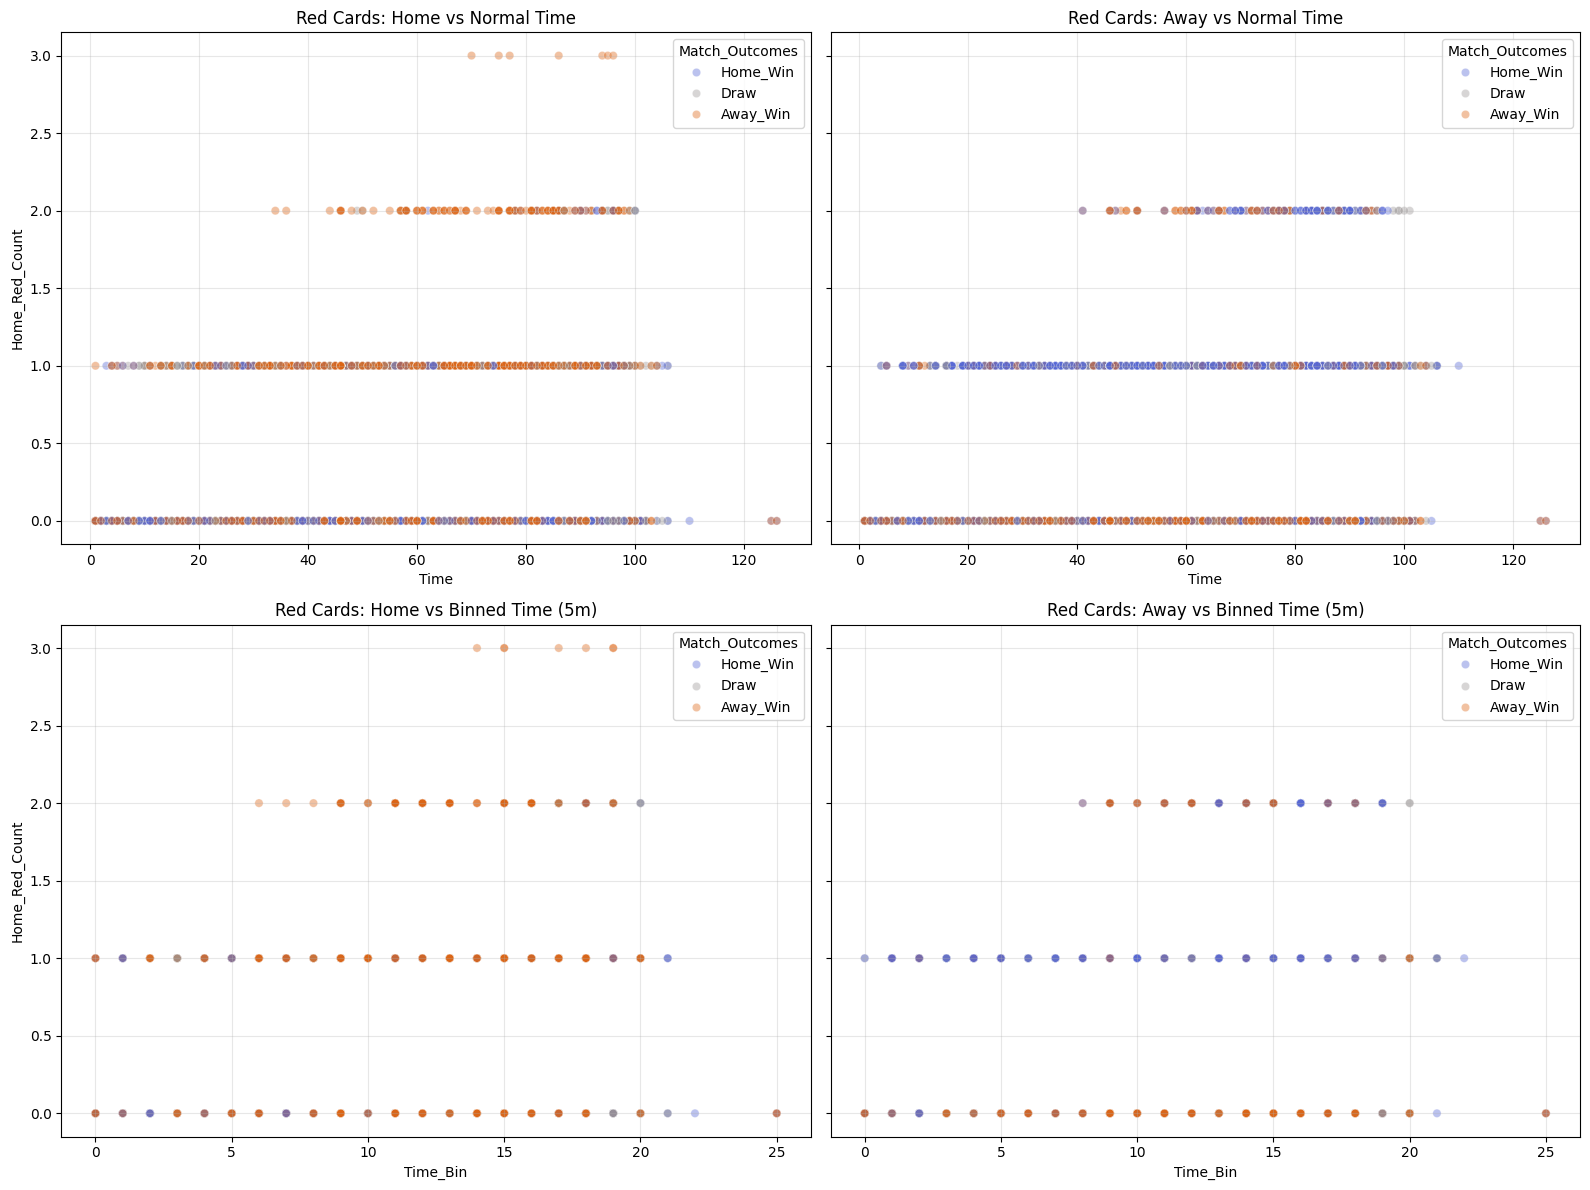

In [14]:
outcome_colors = {'Home_Win': "#5768d5", 'Away_Win': "#dd6515", 'Draw': "#9c9898ff"}

def plot_feature_grid(home_feat, away_feat, title_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
    
    # --- Row 1: Normal Time ---
    sns.scatterplot(data=df_mod, x="Time", y=home_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.4, ax=axes[0, 0])
    axes[0, 0].set_title(f"{title_name}: Home vs Normal Time")
    
    sns.scatterplot(data=df_mod, x="Time", y=away_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.4, ax=axes[0, 1])
    axes[0, 1].set_title(f"{title_name}: Away vs Normal Time")
    
    # --- Row 2: Binned Time ---
    sns.scatterplot(data=df_mod, x="Time_Bin", y=home_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.4, ax=axes[1, 0])
    axes[1, 0].set_title(f"{title_name}: Home vs Binned Time (5m)")
    
    sns.scatterplot(data=df_mod, x="Time_Bin", y=away_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.4, ax=axes[1, 1])
    axes[1, 1].set_title(f"{title_name}: Away vs Binned Time (5m)")
    
    for ax in axes.flat:
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# 1. SCORES Grid
plot_feature_grid("Home_Score", "Away_Score", "Scores")

# 2. SUBSTITUTIONS Grid
plot_feature_grid("Home_Off_Sub_Count", "Away_Off_Sub_Count", "Offensive Substitutions")

# 3. RED CARDS Grid
plot_feature_grid("Home_Red_Count", "Away_Red_Count", "Red Cards")